In [1]:
import dataset
import os
import importlib
from pathlib import Path

importlib.reload(dataset)

# create data loader
path: str=Path(r"F:/Python/SAM2/OCTDatasetOIMHS")
participants = os.listdir(path / "Images")
train_loader, test_loader = dataset.get_dataloader(
    participants=participants,
    train_portion=0.7,
    augment=True,
    max_rotate_deg=0,
    hflip_p=0.5,
    return_numpy=False,
    normalize="none",
    batch_size=16,
    num_workers=0
)

In [2]:
import model
import importlib
importlib.reload(model)

# create the model to train
myModel = model.build_smp_model(
    arch="unet",
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=1,
    classes=1,
    activation=None
)

c:\Users\Bjoern\anaconda3\envs\pytorch211\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
import torch
import segmentation_models_pytorch as smp

bce = torch.nn.BCEWithLogitsLoss()
dice = smp.losses.DiceLoss(mode="binary", from_logits=True)  # [6](https://segmentation-models-pytorch.readthedocs.io/en/latest/losses.html)[7](https://segmentation-models-pytorch.readthedocs.io/en/latest/_modules/segmentation_models_pytorch/losses/dice.html)

def loss_fn(logits, masks):
    return 0.5 * bce(logits, masks) + 0.5 * dice(logits, masks)

In [4]:
#setup optimizer and trainig variables
import torch.optim as optim
optimizer = optim.AdamW(
    myModel.parameters(), 
    lr=1e-3, 
    weight_decay=1e-4)
num_epochs = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
myModel.to(device)

cuda


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [5]:
from tqdm import tqdm
for epoch in range(num_epochs):
    myModel.train()

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}"):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = myModel(images)
        loss = loss_fn(logits, masks)
        loss.backward()
        optimizer.step()

Epoch 10/10: 100%|██████████| 164/164 [10:06<00:00,  3.70s/it]


In [8]:
myModel.eval()

running_loss = 0.0
running_dice = 0.0
running_iou = 0.0
n_batches = 0
threshold=0.5

eps = 1e-7

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Evaluating"):
        images = images.to(device)
        masks = masks.to(device)

        logits = myModel(images)
        loss = loss_fn(logits, masks)
        

        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

        preds_f = preds.view(preds.size(0), -1)
        masks_f = masks.view(masks.size(0), -1)

        intersection = (preds_f * masks_f).sum(dim=1)
        pred_sum = preds_f.sum(dim=1)
        mask_sum = masks_f.sum(dim=1)

        dice_score = (2.0 * intersection + eps) / (pred_sum + mask_sum + eps)

        union = pred_sum + mask_sum - intersection
        iou = (intersection + eps) / (union + eps)

        running_loss += loss.item()
        running_dice += dice_score.sum().item()
        running_iou += iou.sum().item()
        n_batches += images.size(0)

results = {
    "loss": running_loss / n_batches,
    "dice": running_dice / n_batches,
    "iou": running_iou / n_batches
}

Evaluating: 100%|██████████| 78/78 [00:37<00:00,  2.10it/s]


In [34]:
train_loader.dataset.__len__()

2616

In [16]:
images.shape

torch.Size([11, 1, 512, 512])

In [9]:
results

{'loss': 0.0013891233300620859,
 'dice': 0.9747799185141381,
 'iou': 0.9512541848425892}

In [12]:
import torch

torch.save(myModel.state_dict(), "trained_models/first_model.pth")

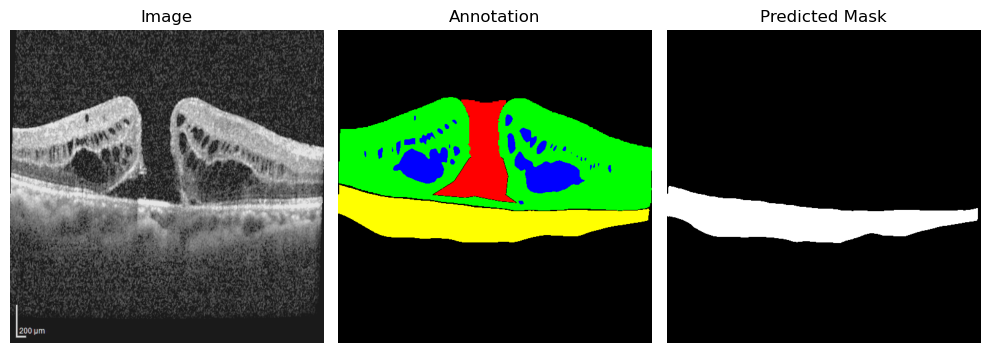

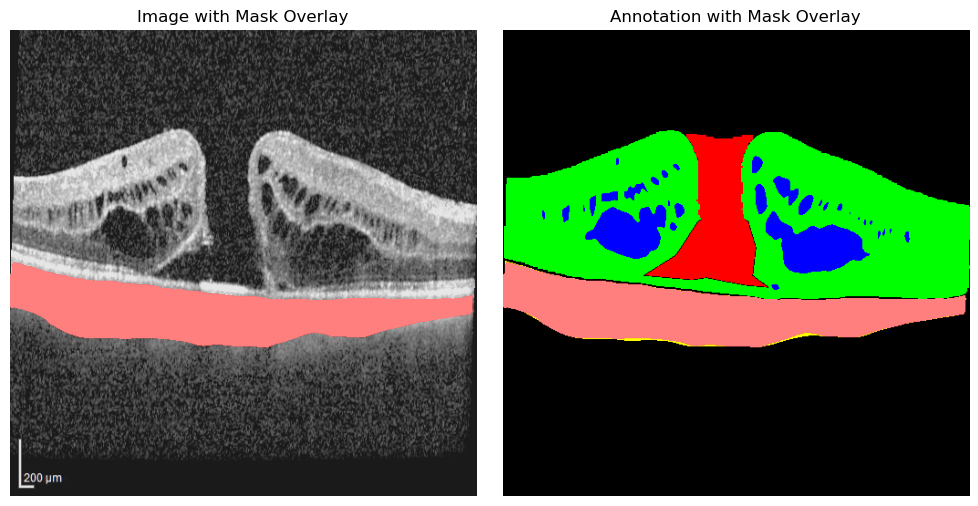

In [33]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

datasetpath = path = r"F:/Python/SAM2/OCTDatasetOIMHS"

images_path = Path(datasetpath) / "Images"
annotations_path = Path(datasetpath) / "Annotations"

pat = test_loader.dataset.participants[-1]
img_nr = 8

img = Image.open(images_path / pat / f"{img_nr}.png")
img_gray = img.convert("L")
img_np = np.array(img_gray, dtype=np.float32)
img_t = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0)

ann = Image.open(annotations_path / pat / f"{img_nr}.png")
# ann_mask = ((ann[:, :, 0] == 255) & (ann[:, :, 1] == 255) & (ann[:, :, 2] == 0)).astype(np.uint8)



myModel.eval()
with torch.no_grad():
    mask = myModel(img_t.to(device))
    mask_np = mask.squeeze().cpu().numpy()


fig, axs = plt.subplots(1, 3, figsize=(10, 5))
axs[0].imshow(img, cmap="gray")
axs[0].set_title("Image")
axs[0].axis("off")

axs[1].imshow(ann, cmap="gray")
axs[1].set_title("Annotation")
axs[1].axis("off")

axs[2].imshow(mask_np>0.5, cmap="gray")
axs[2].set_title("Predicted Mask")
axs[2].axis("off")

plt.tight_layout()
plt.show()

#img and annotation with mask overlay

img_overlay = img.copy().convert("RGBA")
mask_overlay = Image.fromarray((mask_np > 0.5).astype(np.uint8) * 255).convert("L")
red_mask = Image.new("RGBA", img_overlay.size, (255, 0, 0, 128))
img_overlay.paste(red_mask, mask=mask_overlay)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img_overlay)
axs[0].set_title("Image with Mask Overlay")
axs[0].axis("off")

ann_overlay = ann.copy().convert("RGBA")
ann_red_mask = Image.new("RGBA", ann_overlay.size, (255, 0, 0, 128))
ann_overlay.paste(ann_red_mask, mask=mask_overlay) 
axs[1].imshow(ann_overlay)
axs[1].set_title("Annotation with Mask Overlay")
axs[1].axis("off")
plt.tight_layout()
plt.show()